In [1]:
import pandas as pd

# PFAS Cost-Risk Analysis

## Overview
This notebook analyzes the cost-effectiveness of different PFAS treatment scenarios using UCMR5 data.

## Starting Dataset
- Source: `ep_table` from `analysis.ipynb`
- Systems: 26,148 FacilityID(Entry Points), 10,155 PWSID(water systems) with population data


## Objectives
1. Estimate treatment costs for varying regulatory thresholds (4, 8, 12, 20, 40 ng/L)
2. Calculate risk reduction (ng×person/day) for each scenario
3. Determine the cost-effectiveness of different treatment targets
4. Visualize trade-offs between costs and public health benefits

In [2]:
df = pd.read_csv('ep_table.csv')

In [3]:
df.head()

,PWSID,FacilityID,PFOA,PFOS,exceeds,POPULATION_SERVED_COUNT,Ep_Population,Population_bin
0,AK2110342,29349,0.0,0.0,False,38526.0,19263.0,"10,001 - 50,000"
1,AK2110342,29360,0.0,0.0,False,38526.0,19263.0,"10,001 - 50,000"
2,AK2110601,10001,0.0,0.0,False,10947.0,5473.5,"3,301 - 10,000"
3,AK2110601,10004,0.0,0.0,False,10947.0,5473.5,"3,301 - 10,000"
4,AK2120232,TP001,0.0,0.0,False,8937.0,8937.0,"3,301 - 10,000"


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26148 entries, 0 to 26147
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   PWSID                    26148 non-null  object 
 1   FacilityID               26148 non-null  object 
 2   PFOA                     26148 non-null  float64
 3   PFOS                     26148 non-null  float64
 4   exceeds                  26148 non-null  bool   
 5   POPULATION_SERVED_COUNT  26148 non-null  float64
 6   Ep_Population            26148 non-null  float64
 7   Population_bin           26148 non-null  object 
dtypes: bool(1), float64(4), object(3)
memory usage: 1.4+ MB


In [5]:
total_exceeding_facilities = df["exceeds"].sum()

print(f'Total PWSID -> {df['PWSID'].nunique()}')
print(f'Total FacilityID (Entry Points) -> {len(df)}')
print(f'Entry points exceeding 80% Threshold (more than 0.0032 µg/L threshold)-> {total_exceeding_facilities}')
print(f"Percentage: {total_exceeding_facilities / len(df) * 100:.1f}%")

Total PWSID -> 10155
Total FacilityID (Entry Points) -> 26148
Entry points exceeding 80% Threshold (more than 0.0032 µg/L threshold)-> 2214
Percentage: 8.5%


In [6]:
df['FacilityID'].nunique()

9265

### PFAS Threshold Exceedance (4–40 ng/L)

Our dataset reports PFOA and PFOS in µg/L, we convert thresholds from ng/L → µg/L:

- 4 ng/L → 0.004 µg/L  
- 8 ng/L → 0.008 µg/L  
- 12 ng/L → 0.012 µg/L  
- 20 ng/L → 0.020 µg/L  
- 40 ng/L → 0.040 µg/L  


For each threshold, we create a column (`exceeds_4`, `exceeds_8`, …) that is True if `PFOA` or `PFOS`  exceeds the converted value.

These columns define which systems would require treatment under different regulatory scenarios.


In [7]:
df['Total_PFAS'] = df['PFOA'] + df['PFOS']

In [8]:
threshold_ng = [4,8,12,20,40]

for t in threshold_ng:
    col_name = f"exceeds_{t}"
    threshold_ug = t / 1000 # convert ng/L ->  µg/L
    df[col_name] = (df['PFOA'] > threshold_ug) | (df['PFOS'] > threshold_ug) # should exceed either chemicals

In [9]:
df.sample(10)

,PWSID,FacilityID,PFOA,PFOS,exceeds,POPULATION_SERVED_COUNT,Ep_Population,Population_bin,Total_PFAS,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40
25826,WI4710457,00081,0.0,0.0,False,63000.0,63000.000000,"50,001 - 100,000",0.0,False,False,False,False,False
11700,MI0001260,TP106,0.0,0.0,False,3520.0,1173.333333,"1,001 - 3,300",0.0,False,False,False,False,False
22517,TX1013343,EP001,0.0,0.0,False,6993.0,6993.000000,"3,301 - 10,000",0.0,False,False,False,False,False
20038,RI1647515,10034,0.0,0.0,False,49000.0,49000.000000,"10,001 - 50,000",0.0,False,False,False,False,False
18701,OR4100635,00005,0.0,0.0,False,50003.0,8333.833333,"3,301 - 10,000",0.0,False,False,False,False,False
18503,OK2007003,90008,0.0,0.0,False,11442.0,1907.000000,"1,001 - 3,300",0.0,False,False,False,False,False
25425,WA5399150,00008,0.0,0.0,False,110899.0,22179.800000,"10,001 - 50,000",0.0,False,False,False,False,False
8853,IL1155150,TP01,0.0,0.0,False,7850.0,7850.000000,"3,301 - 10,000",0.0,False,False,False,False,False
25511,WI1140142,00001,0.0,0.0,False,3706.0,3706.000000,"3,301 - 10,000",0.0,False,False,False,False,False
1900,AZ0414004,00363,0.0,0.0,False,32425.0,6485.000000,"3,301 - 10,000",0.0,False,False,False,False,False


In [10]:
# rearranging the columns
df = df[
    [
        "PWSID",
        "FacilityID",
        "PFOA",
        "PFOS",
        "Total_PFAS",
        "POPULATION_SERVED_COUNT",
        "Ep_Population",
        "Population_bin",
        "exceeds",
        "exceeds_4",
        "exceeds_8",
        "exceeds_12",
        "exceeds_20",
        "exceeds_40",
    ]
]
df.sample(10)

,PWSID,FacilityID,PFOA,PFOS,Total_PFAS,POPULATION_SERVED_COUNT,Ep_Population,Population_bin,exceeds,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40
8308,ID6030043,00019,0.0,0.0000,0.0000,57092.0,9515.333333,"3,301 - 10,000",False,False,False,False,False,False
13818,MS0480001,TF103,0.0,0.0000,0.0000,7783.0,707.545455,"501 - 1,000",False,False,False,False,False,False
14772,NC0408085,10230,0.0,0.0000,0.0000,12893.0,1172.090909,"1,001 - 3,300",False,False,False,False,False,False
21257,TX0250019,EP002,0.0,0.0000,0.0000,7575.0,3787.500000,"3,301 - 10,000",False,False,False,False,False,False
8199,ID4010066,11262,0.0,0.0000,0.0000,12500.0,1562.500000,"1,001 - 3,300",False,False,False,False,False,False
19867,PR0003824,00013,0.0,0.0026,0.0026,111926.0,4866.347826,"3,301 - 10,000",False,False,False,False,False,False
1902,AZ0414004,00366,0.0,0.0000,0.0000,32425.0,6485.000000,"3,301 - 10,000",False,False,False,False,False,False
22455,TX1012542,EP001,0.0,0.0000,0.0000,4266.0,4266.000000,"3,301 - 10,000",False,False,False,False,False,False
25968,WV3300512,TP001,0.0,0.0000,0.0000,4970.0,4970.000000,"3,301 - 10,000",False,False,False,False,False,False
12722,MO2024377,CC01,0.0,0.0000,0.0000,4900.0,1225.000000,"1,001 - 3,300",False,False,False,False,False,False


In [11]:
# Ep_Population is population served per entry point (total population / number of entry points)
# This calculation produces floats, so we round to whole numbers for clarity
df['Ep_Population'] = df['Ep_Population'].round()

In [12]:
print("=== Number of Entry Points Exceeding Each Threshold ===")
for t in threshold_ng:
    col = f"exceeds_{t}"
    count = df[col].sum()
    percent = (count / len(df)) * 100
    pop = df.loc[df[col] == 1, "Ep_Population"].sum()
    print(f"{t} ng/L: {count:,} FacilityId/EntryPoints ({percent:.2f}%), Population affected: {pop:,}")

=== Number of Entry Points Exceeding Each Threshold ===
4 ng/L: 2,078 FacilityId/EntryPoints (7.95%), Population affected: 28,772,056.0
8 ng/L: 944 FacilityId/EntryPoints (3.61%), Population affected: 13,123,092.0
12 ng/L: 481 FacilityId/EntryPoints (1.84%), Population affected: 7,923,771.0
20 ng/L: 186 FacilityId/EntryPoints (0.71%), Population affected: 2,995,707.0
40 ng/L: 39 FacilityId/EntryPoints (0.15%), Population affected: 307,375.0


### Risk Reduction Based on Drinking Water Intake (ng/day)

The EPA assumes the average adult consumes 2 liters per day of tap water.  
Therefore, PFAS exposure per facility id is estimated as:

$$
\text{ng/day total} = (\text{PFOA} + \text{PFOS})_{\mu g/L} 
\times 2\ \text{L/day/person} 
\times \text{Population Served} 
\times 1000\ \text{ng}/\mu g
$$


This value represents the total PFAS exposure per day for all people served by that entry point.


In [13]:
df["exposure_per_day(ng)"] = (df["Total_PFAS"] * 1000 * 2 * df["Ep_Population"])

In [14]:
df.sample(10)

,PWSID,FacilityID,PFOA,PFOS,Total_PFAS,POPULATION_SERVED_COUNT,Ep_Population,Population_bin,exceeds,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40,exposure_per_day(ng)
208,AL0000255,TP101,0.0048,0.01700,0.02180,5280.0,1320.0,"1,001 - 3,300",True,True,True,True,False,False,57552.0
25661,WI2670110,00012,0.0000,0.00000,0.00000,15805.0,3161.0,"1,001 - 3,300",False,False,False,False,False,False,0.0
24027,UTAH22137,TP026,0.0000,0.00000,0.00000,8245.0,1374.0,"1,001 - 3,300",False,False,False,False,False,False,0.0
22526,TX1013479,EP001,0.0000,0.00000,0.00000,5025.0,5025.0,"3,301 - 10,000",False,False,False,False,False,False,0.0
1358,AZ0407045,TPGW001,0.0000,0.00000,0.00000,6481.0,1296.0,"1,001 - 3,300",False,False,False,False,False,False,0.0
6278,FL2010207,3,0.0024,0.00000,0.00240,3885.0,1942.0,"1,001 - 3,300",False,False,False,False,False,False,9321.6
14219,MT0003229,03229,0.0000,0.00205,0.00205,125.0,125.0,101 - 500,False,False,False,False,False,False,512.5
12089,MI0006910,05369,0.0000,0.00000,0.00000,73441.0,6120.0,"3,301 - 10,000",False,False,False,False,False,False,0.0
26140,WY5601254,20001,0.0000,0.00000,0.00000,7330.0,7330.0,"3,301 - 10,000",False,False,False,False,False,False,0.0
24761,WA5323600,00001,0.0000,0.00000,0.00000,17425.0,4356.0,"3,301 - 10,000",False,False,False,False,False,False,0.0


In [15]:
# This adds up the total PFAS amount per day (ng/day) from all entry points
# that exceed each threshold.
pfas_exposure_by_threshold = {}

for t in threshold_ng:
    column = f"exceeds_{t}"
    ng_sum = (df['exposure_per_day(ng)'] * df[column]).sum()
    pfas_exposure_by_threshold[t] = round(float(ng_sum), 2)
    
pfas_exposure_by_threshold

{4: 852782850.93,
 8: 593140388.48,
 12: 442956224.78,
 20: 242658073.3,
 40: 40824148.7}

In [16]:
# sum the population served for all water systems (PWS) that exceed each PFAS regulatory threshold
population_by_threshold = {}

for t in threshold_ng:
    cols = f"exceeds_{t}"
    population_sum = df.loc[df[cols],'Ep_Population'].sum()
    population_by_threshold[t] = int(population_sum)
    
population_by_threshold

{4: 28772056, 8: 13123092, 12: 7923771, 20: 2995707, 40: 307375}

### Average PFAS Exposure Reduction (ng/day/person)

To describe how PFAS burden is distributed among affected populations, we divide the total PFAS burden proxy (ng/day) from all **entry points** exceeding a given threshold by the total population served by those entry points:

$$
\text{ng/day/person}_T
=
\frac{\text{ng/day total}_T}{\text{Population}_T}
$$

This represents the average PFAS mass per person per day among people served by Facility ID exceeding threshold \(T\).

In [17]:
# This calculates average PFAS per person per day for populations served
# by entry points exceeding each threshold.
ng_day_per_person = {}

for t in threshold_ng:
    total_ng = pfas_exposure_by_threshold[t]         # total ng/day
    total_pop = population_by_threshold[t]           # total population
    
  
    value = (total_ng / total_pop) if total_pop > 0 else 0
    ng_day_per_person[t] = round(value, 2)

ng_day_per_person

{4: 29.64, 8: 45.2, 12: 55.9, 20: 81.0, 40: 132.82}

### National Scaling Methodology: Brief Overview

To move from the UCMR5 sample to a National Estimate, we followed these core steps:

- **Total Active Water Systems:**  
  Determined the total count of Public Water Systems (PWSs) using SDWIS inventory data to establish the true size of U.S. infrastructure.

- **Impacted Entry Points (EPs):**  
  Used the UCMR5 dataset to calculate the impact rate by dividing the number of systems exceeding a specific threshold by the total number of systems in the cleaned dataset.

- **Vector Calculation:**  
  Created a vector across all population bins to total EPs in UCMR5, and divided the "# impacted systems" vector by the "total systems" vector to compute the percentage of impacted systems for each threshold.

- **National Scaling:**  
  Applied these percentages to the total national PWS count to scale the findings to represent the entire United States.

This Scaling Table represents the final result of that process. It summarizes the total national population protected, the mass of PFAS removed, and the total annual cost for the entire country.

- **Note:**  For the full step-by-step calculations, population updates, and Python logic, please check out the Scaling Notebook in the project directory.


In [18]:
scaling_table = pd.read_csv('final_national_impact.csv')

In [19]:
scaling_table

,Population_bin,National_PWS_Count,Estimated_EPs_to_Treat_4ng,Estimated_EPs_to_Treat_8ng,Estimated_EPs_to_Treat_12ng,Estimated_EPs_to_Treat_20ng,Estimated_EPs_to_Treat_40ng
0,25 - 100,11385,2973.0,850.0,425.0,425.0,425.0
1,101 - 500,15098,2305.0,801.0,400.0,101.0,101.0
2,"501 - 1,000",5336,1723.0,878.0,595.0,250.0,47.0
3,"1,001 - 3,300",7972,2174.0,1193.0,667.0,310.0,94.0
4,"3,301 - 10,000",5000,1582.0,747.0,380.0,154.0,27.0
5,"10,001 - 50,000",3513,1084.0,516.0,305.0,147.0,26.0
6,"50,001 - 100,000",583,138.0,63.0,39.0,12.0,4.0
7,"100,001 - 1,000,000",455,189.0,71.0,65.0,18.0,0.0
8,"> 1,000,000",27,0.0,0.0,0.0,0.0,0.0


### National PFAS Exposure & Population Scaling

- **National Population Protected:**  
  Calculated the number of people served by water systems exceeding each threshold, then multiplied by the national multiplier \( M = 2.5749 \) to estimate the total number of Americans receiving cleaner water.

- **National PFAS Exposure Removed:**  
  Summed the total mass of PFOA and PFOS removed daily (\( g/day \)) and applied the same multiplier to estimate the reduction in the national chemical burden.

- **Scaling Logic:**  
  Assumed that the concentration and population patterns observed in the 26,000+ entry point sample are representative of water systems across the entire United States.

In [20]:
national_multiplier = 2.5749

national_pfas_exposure = {t: pfas_exposure_by_threshold[t] * national_multiplier for t in threshold_ng}
national_population = {t: population_by_threshold[t] * national_multiplier for t in threshold_ng}

In [21]:
national_pfas_exposure_df = (
    pd.DataFrame.from_dict(national_pfas_exposure, orient="index", columns=["exposure"])
      .reset_index()
      .rename(columns={"index": "threshold"})
)
national_pfas_exposure_df

,threshold,exposure
0,4,2.195831e+09
1,8,1.527277e+09
2,12,1.140568e+09
3,20,6.248203e+08
4,40,1.051181e+08


In [22]:
national_population_df = (
    pd.DataFrame.from_dict(national_population, orient="index", columns=["population"])
      .reset_index()
      .rename(columns={"index": "threshold"})
)
national_population_df

,threshold,population
0,4,7.408517e+07
1,8,3.379065e+07
2,12,2.040292e+07
3,20,7.713646e+06
4,40,7.914599e+05


In [23]:
# National PFAS exposure per person (ng/day/person) for each threshold

scaled_ng_day_per_person = {}
for t in threshold_ng:
    national_ng = pfas_exposure_by_threshold[t] * national_multiplier
    national_pop = population_by_threshold[t] * national_multiplier
    scaled_ng_day_per_person[t] = round(national_ng / national_pop, 2)
scaled_ng_day_per_person

{4: 29.64, 8: 45.2, 12: 55.9, 20: 81.0, 40: 132.82}

The values remain same after scaling this PFAS exposure per person (ng/day/person) for each threshold becuase in the previous scaling, we calculated the average exposure using only the entry points in our ucmr5 dataset.

Now We multiply both the total PFAS mass and the total population by the same national multiplier ($M = 2.5749$). 

Since the multiplier is in both the numerator and denominator, it cancels out.

This confirms that while the national totals have grown to reflect the entire U.S., the average intensity of exposure removed per person remains accurate and unchanged.

### National Annualized Cost Calculation

- **Cost Mapping:**  
  Assigned an annual cost per entry point based on population bins using engineering estimates from the Corona memo.

- **Bin-by-Bin Calculation:**  
  For each threshold, multiply the estimated national number of entry points in each bin by its corresponding cost factor (e.g., $0.07M for the smallest systems, $4.76M for the largest).

- **National Total:**  
  Summed costs across all bins to estimate total annual investment ($M/year) for the United States.

In [24]:
# mapping population bin with facility annualized cost column of Table 4 in the Corona memo
popbin_cost_map = {
    '25 - 100': 0.07, '101 - 500': 0.12, '501 - 1,000': 0.17,
    '1,001 - 3,300': 0.25, '3,301 - 10,000': 0.40, '10,001 - 50,000': 0.76,
    '50,001 - 100,000': 1.29, '100,001 - 1,000,000': 2.33, '> 1,000,000': 4.76
}

national_costs = {}

for t in threshold_ng:
  
    ep_col = f'Estimated_EPs_to_Treat_{t}ng'
    
    # Cost = Sum of (National EPs in Bin * Bin's Annualized Cost)
    bin_total = (scaling_table[ep_col] * scaling_table['Population_bin'].map(popbin_cost_map)).sum()
    national_costs[t] = round(bin_total, 2)

print("National Annualized Costs ($M):", national_costs)

National Annualized Costs ($M): {4: np.float64(3396.15), 8: np.float64(1540.79), 12: np.float64(931.21), 20: np.float64(392.61), 40: np.float64(109.08)}


### National Cost-Effectiveness Calculation

Evaluates economic efficiency by measuring how many dollars are required to remove one nanogram of PFAS from the national water supply.

- **Dollar Conversion:**  
  Converted costs from millions ($M$) to actual dollars by multiplying by \( 1{,}000{,}000 \) (1e6).

- **Annual Mass Conversion:**  
  Converted daily PFAS removal (\( ng/day \)) to annual removal by multiplying by 365 days.

- **Efficiency Ratio:**  
  Divided total annual cost by the total annual PFAS removed.

In [25]:
ce_results = []

for t in threshold_ng:
    total_annual_cost_dollars = national_costs[t] * 1e6  # Convert $M to actual dollars
    annual_ng_reduction = national_pfas_exposure[t] * 365 # Convert ng/day to ng/year
    
    cost_effectiveness = total_annual_cost_dollars / annual_ng_reduction
    
    ce_results.append({
        "Threshold (ng/L)": t,
        "Total Annual Cost ($M)": national_costs[t],
        "Annual Exposure Reduction (ng)": annual_ng_reduction,
        "Cost-Effectiveness ($/ng)": round(cost_effectiveness, 9) 
    })

cost_effectiveness_df = pd.DataFrame(ce_results)
cost_effectiveness_df

,Threshold (ng/L),Total Annual Cost ($M),Annual Exposure Reduction (ng),Cost-Effectiveness ($/ng)
0,4,3396.15,8.014782e+11,0.004237
1,8,1540.79,5.574562e+11,0.002764
2,12,931.21,4.163073e+11,0.002237
3,20,392.61,2.280594e+11,0.001722
4,40,109.08,3.836811e+10,0.002843


In [26]:
# Create the final National Impact Summary Table
summary_results = []

for t in threshold_ng:
    # Pulling from the dictionaries and dataframes 
    cost = national_costs[t]
    exposure_daily = national_pfas_exposure[t]
    population = national_population[t]
    
    # Calculate annual reduction for the $/ng metric
    annual_reduction_ng = exposure_daily * 365
    ce_value = (cost * 1e6) / annual_reduction_ng
    
    summary_results.append({
        "Threshold (ng/L)": t,
        "Total National Cost ($M)": cost,
        "Daily Exposure Reduction (ng/day)": round(exposure_daily, 2),
        "National Population Protected": int(population),
        "Cost-Effectiveness ($/ng)": f"{ce_value:.10f}" # Shows the full decimal
    })

summary_df = pd.DataFrame(summary_results)


summary_df

,Threshold (ng/L),Total National Cost ($M),Daily Exposure Reduction (ng/day),National Population Protected,Cost-Effectiveness ($/ng)
0,4,3396.15,2.195831e+09,74085166,0.0042373582
1,8,1540.79,1.527277e+09,33790649,0.0027639662
2,12,931.21,1.140568e+09,20402917,0.0022368331
3,20,392.61,6.248203e+08,7713645,0.0017215252
4,40,109.08,1.051181e+08,791459,0.0028429863


### Figure 1: Total PFAS Exposure Removed (ng/day) vs National Annualized Cost

This figure shows the total PFAS burden proxy (ng/day) removed nationwide under each regulatory threshold, plotted against the corresponding national annualized treatment cost (million dollars). Lower thresholds remove a larger share of the total PFAS burden but require higher treatment costs, while higher thresholds remove less PFAS burden at lower cost. Results are based on Corona-scaled entry-point (Facility ID) exceedances.


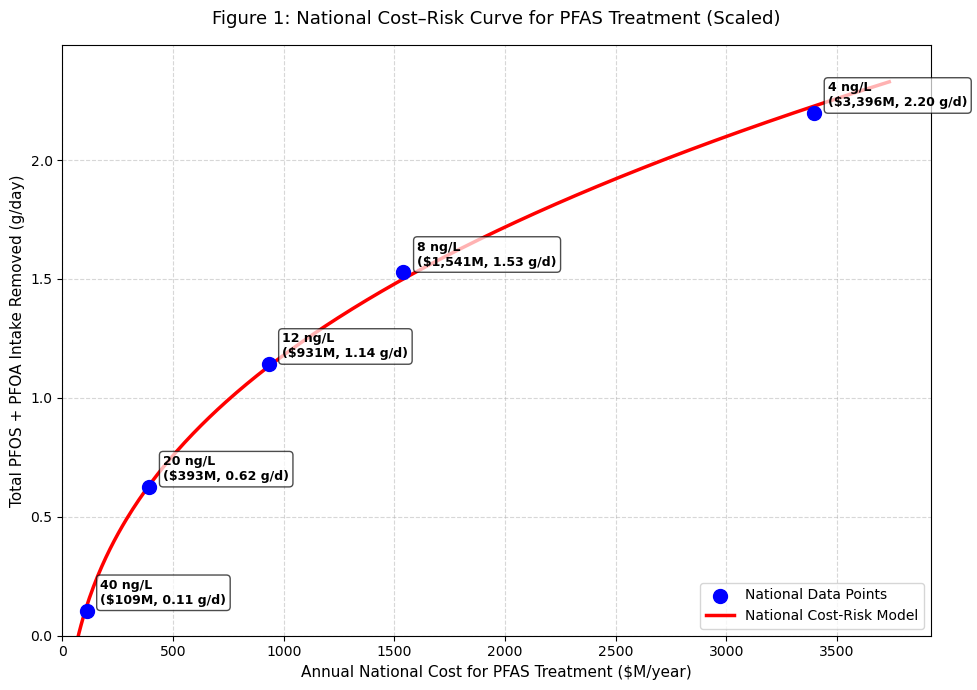

In [27]:
import numpy as np
import matplotlib.pyplot as plt


fig1_costs_M = np.array([national_costs[t] for t in threshold_ng]) # $M
fig1_exposure = np.array([national_pfas_exposure[t] / 1e9 for t in threshold_ng]) # g/day


x_range = np.linspace(0, fig1_costs_M.max() * 1.1, 400)

y_curve = -0.78 + 1.96 * ((x_range / 1000) ** 0.35)


plt.figure(figsize=(10, 7))
plt.scatter(fig1_costs_M, fig1_exposure, color='blue', s=100, label='National Data Points', zorder=3)
plt.plot(x_range, y_curve, color='red', linewidth=2.5, label='National Cost-Risk Model', zorder=2)


for t, x, y in zip(threshold_ng, fig1_costs_M, fig1_exposure):
    label = f"{t} ng/L\n(${x:,.0f}M, {y:,.2f} g/d)"
    plt.annotate(label, (x, y), textcoords="offset points", xytext=(10, 5), 
                 fontsize=9, fontweight='bold', bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

# Formatting
plt.xlabel("Annual National Cost for PFAS Treatment ($M/year)", fontsize=11)
plt.ylabel("Total PFOS + PFOA Intake Removed (g/day)", fontsize=11)
plt.title("Figure 1: National Cost–Risk Curve for PFAS Treatment (Scaled)", fontsize=13, pad=15)
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right')
plt.tight_layout()

# Save the figure
plt.savefig('national_cost_risk_curve_updated.png')
plt.show()

### Figure 1a: Average Per-Person PFAS Burden Proxy by Threshold
This figure shows the average PFAS burden proxy per person per day (ng/day/person) among populations served by entry points exceeding each regulatory threshold. As thresholds increase, fewer people remain affected, but those remaining experience higher average PFAS burden. The figure illustrates how PFAS burden becomes increasingly concentrated among affected populations.

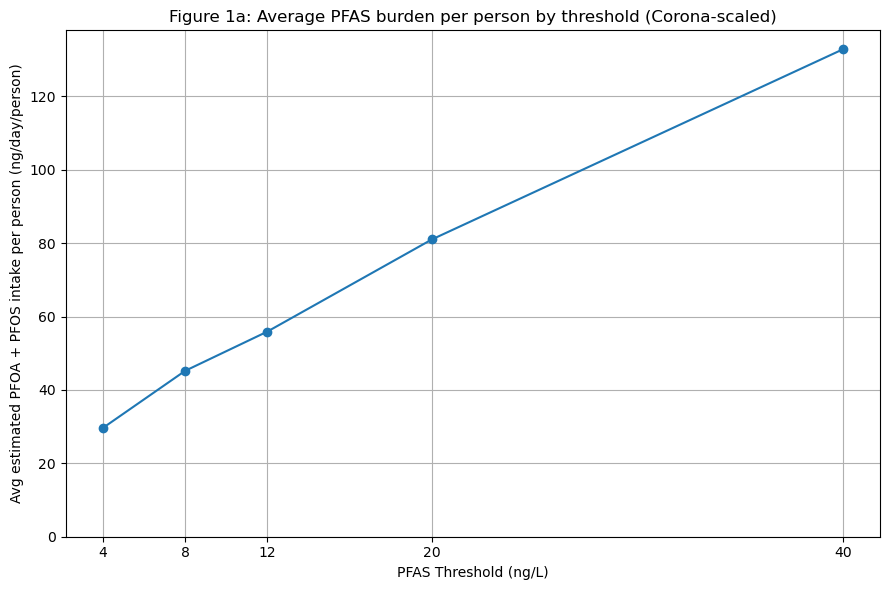

In [28]:
fig1a_exposure = [scaled_ng_day_per_person[t] for t in threshold_ng]  # ng/day/person 

plt.figure(figsize=(9,6))
plt.plot(threshold_ng, fig1a_exposure, marker='o')

plt.xlabel("PFAS Threshold (ng/L)")
plt.ylabel("Avg estimated PFOA + PFOS intake per person (ng/day/person)")
plt.title("Figure 1a: Average PFAS burden per person by threshold (Corona-scaled)")
plt.ylim(bottom=0)
plt.grid(True)
plt.xticks(threshold_ng)
plt.tight_layout()
plt.show()

### Figure 1b: National Average PFOA + PFOS Concentration Among Treated Entry Points (Scaled)

This figure shows the national population-weighted average combined PFAS concentration (PFOA + PFOS, ng/L) among entry points that would require treatment at each regulatory threshold. 

By using the National Multiplier ($M = 2.5749$), we scale our UCMR5 sample to represent the entire United States. While the total number of affected systems increases, the weighted average concentration remains a robust estimate of the water quality challenge facing treated systems nationwide.

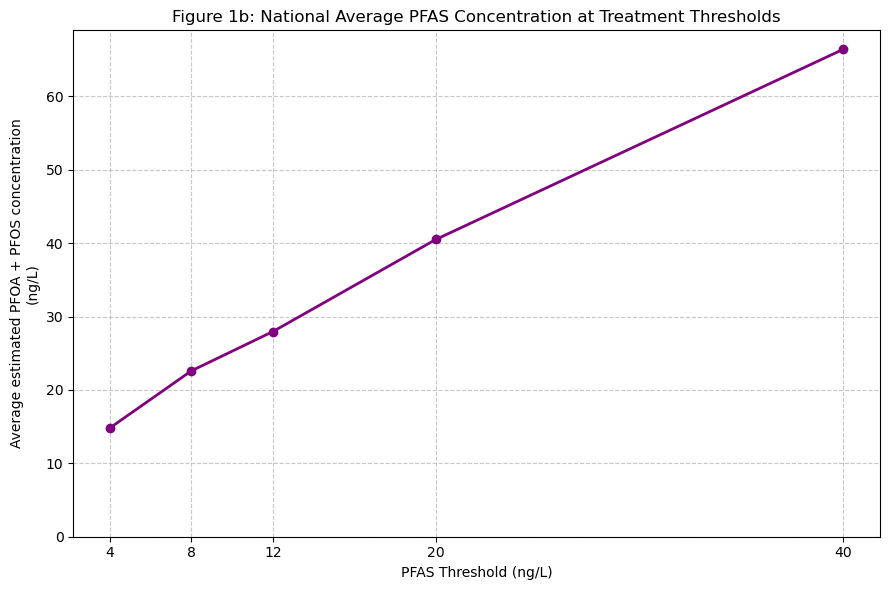

In [29]:
# Compute National population-weighted mean concentration (ng/L) 
# among systems treated at each threshold
national_avg_conc_by_threshold = {}

for t in threshold_ng:
    col = f'exceeds_{t}'
    
    # Filter for only the entry points that exceed the threshold
    treated_mask = df[col] == True
    
    # Population-weighted average: sum(Conc * Pop) / sum(Pop)
    # Note: Total_PFAS is already in µg/L in your df, so we multiply by 1000 for ng/L
    numerator = (df.loc[treated_mask, 'Total_PFAS'] * 1000 * df.loc[treated_mask, 'Ep_Population']).sum()
    denominator = df.loc[treated_mask, 'Ep_Population'].sum()
    
    avg_conc = (numerator/denominator) if denominator > 0 else 0
    national_avg_conc_by_threshold[t] = round(avg_conc, 2)

# Prepare data for plotting
fig1b_conc = [national_avg_conc_by_threshold[t] for t in threshold_ng]

# --- Plotting ---
plt.figure(figsize=(9,6))
plt.plot(threshold_ng, fig1b_conc, marker='o', color='purple', linewidth=2)

plt.xlabel('PFAS Threshold (ng/L)')
plt.ylabel("Average estimated PFOA + PFOS concentration\n(ng/L)")
plt.title('Figure 1b: National Average PFAS Concentration at Treatment Thresholds')
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(threshold_ng)
plt.tight_layout()
plt.show()

### Figure 2: National Cost-Effectiveness of PFAS Treatment by Threshold

This figure shows the economic efficiency for each threshold. We calculate this by dividing the total annual cost by the total weight (in grams) of PFAS removed each year. A lower value on the graph means the threshold is more efficient. It represents the price to remove one gram of PFAS from the national water supply. These results are scaled to the national level using the verified multiplier ($M = 2.5749$).

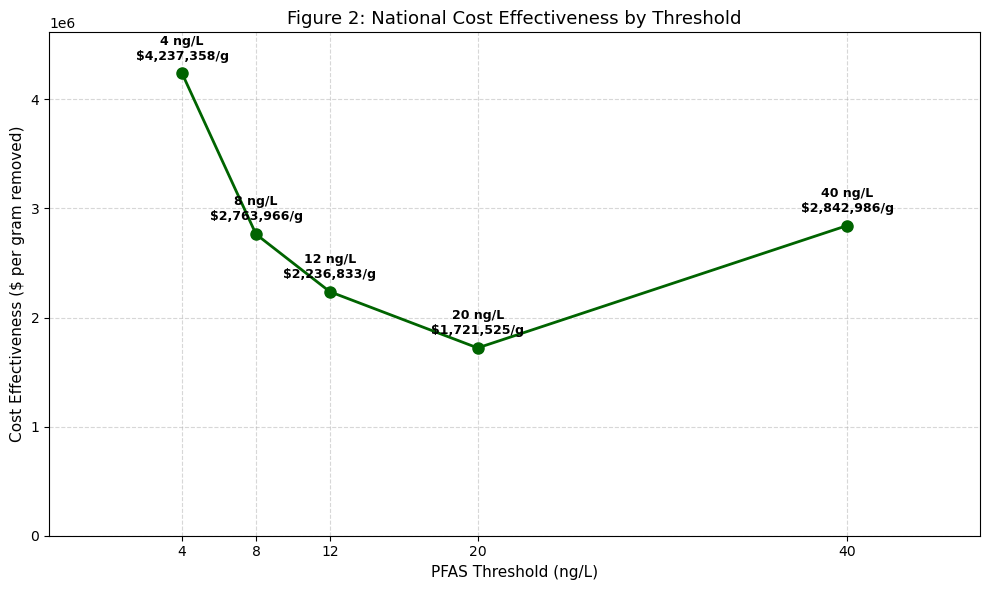

In [30]:
# multiply $/ng by 1e9 to get $/gram
ce_vals_per_gram = []
for t in threshold_ng:
    # Get the value from the 'Cost-Effectiveness ($/ng)' column
    val_ng = cost_effectiveness_df.loc[cost_effectiveness_df['Threshold (ng/L)'] == t, 'Cost-Effectiveness ($/ng)'].values[0]
    ce_vals_per_gram.append(float(val_ng) * 1e9)
    
plt.figure(figsize=(10, 6))
plt.plot(threshold_ng, ce_vals_per_gram, marker='o', color='darkgreen', linewidth=2, markersize=8)

# add space for labels
plt.margins(x=0.2, y=0.15)


for t, y in zip(threshold_ng, ce_vals_per_gram):
    plt.annotate(
        f"{t} ng/L\n${y:,.0f}/g", 
        (t, y),
        textcoords="offset points",
        xytext=(0, 10),
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.xlabel("PFAS Threshold (ng/L)", fontsize=11)
plt.ylabel("Cost Effectiveness ($ per gram removed)", fontsize=11)
plt.title("Figure 2: National Cost Effectiveness by Threshold", fontsize=13)
plt.ylim(bottom=0)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xticks(threshold_ng)
plt.tight_layout()
plt.show()

In [31]:
overall_exceedance = {}

total_systems = len(df)

for t in threshold_ng:
    col = f"exceeds_{t}"
    overall_exceedance[t] = df[col].mean() * 100   # % of entry points

### Figure 3: Percent of Entry Points Exceeding PFAS Thresholds

This figure shows (1) the percent of drinking-water entry points within each population bin that exceed each PFAS threshold, and (2) the overall percent of all U.S. entry points exceeding each threshold. Results are based on UCMR5 observations and reported for descriptive comparison across system sizes.


In [32]:
# compute percentage % exceeding per bin
exceed_by_bin = df.groupby("Population_bin")[[f"exceeds_{t}" for t in threshold_ng]].mean() * 100

# reorder bins properly if needed
bin_order = ['25 - 100','101 - 500','501 - 1,000','1,001 - 3,300',
             '3,301 - 10,000','10,001 - 50,000','50,001 - 100,000',
             '100,001 - 1,000,000','> 1,000,000']

exceed_by_bin = exceed_by_bin.reindex(bin_order)


In [33]:
exceed_by_bin

,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40
Population_bin,,,,,
25 - 100,6.923077,1.538462,0.769231,0.769231,0.769231
101 - 500,4.552352,1.820941,0.758725,0.303490,0.303490
"501 - 1,000",7.017544,3.338993,2.150538,0.905490,0.169779
"1,001 - 3,300",7.217538,3.530073,1.675098,0.663294,0.191119
"3,301 - 10,000",8.178399,3.406771,1.601290,0.580333,0.085975
"10,001 - 50,000",9.394761,4.313460,2.393857,0.948509,0.158085
"50,001 - 100,000",8.688525,4.918033,2.950820,1.475410,0.163934
"100,001 - 1,000,000",12.356322,5.459770,4.310345,0.862069,0.000000
"> 1,000,000",0.000000,0.000000,0.000000,0.000000,0.000000


<Figure size 1600x800 with 0 Axes>

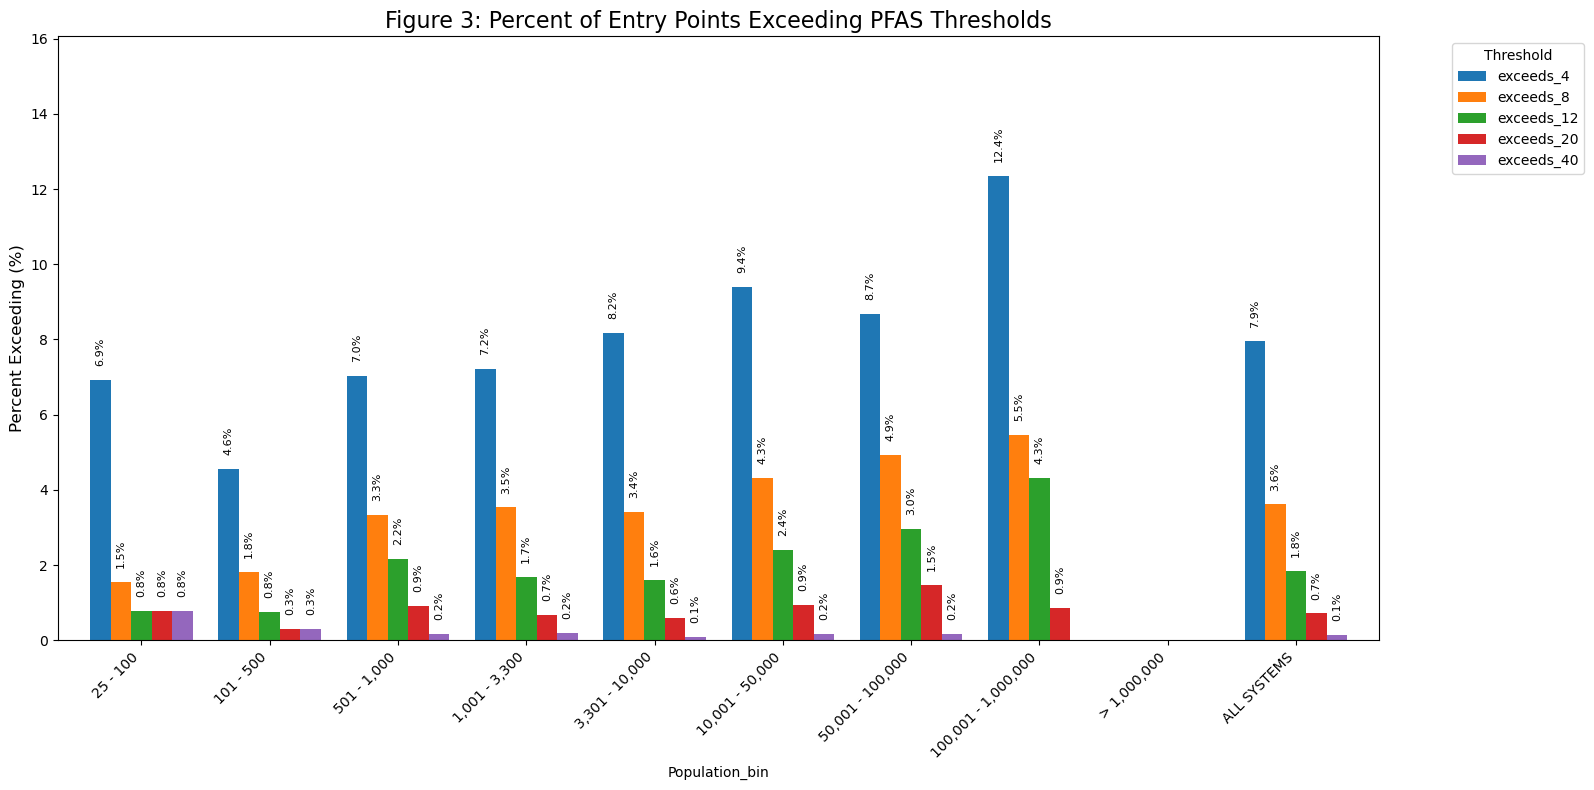

In [34]:
exceed_by_bin.loc["ALL SYSTEMS"] = [overall_exceedance[t] for t in threshold_ng]

plt.figure(figsize=(16, 8))
ax = exceed_by_bin.plot(kind='bar', figsize=(16, 8), width=0.8)

for p in ax.patches:
    height = p.get_height()
    if height > 0: 
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    fontsize=8,
                    rotation=90,
                    xytext=(0, 10), 
                    textcoords='offset points')
        
plt.title("Figure 3: Percent of Entry Points Exceeding PFAS Thresholds", fontsize=16)
plt.ylabel("Percent Exceeding (%)", fontsize=12)
plt.ylim(0, exceed_by_bin.max().max() * 1.3) 
plt.xticks(rotation=45, ha='right')
plt.legend(title="Threshold", bbox_to_anchor=(1.05, 1), loc='upper left') 
plt.tight_layout()
plt.show()

```ALL SYSTEMS``` is the national benchmark or the national average. It represents the big picture of the entire country, ignoring population size categories for a moment. It provides a point of comparison to determine if specific community sizes are disproportionately affected by PFAS contamination compared to the country at large.

### Figure 3A: Distribution of Max(PFOA, PFOS) Concentrations by Population Size
This figure shows the actual range of PFAS levels found in different water systems.

Two versions of this graph:

Normal (Linear) Scale: Best for seeing the true physical difference between high and low values. However, very high "outlier" points can make the lower boxes look squashed.

Log Scale: Best for seeing the detail in lower concentrations. It uses powers of 10 on the vertical axis, which prevents the high outliers from hiding the patterns in the rest of the data.

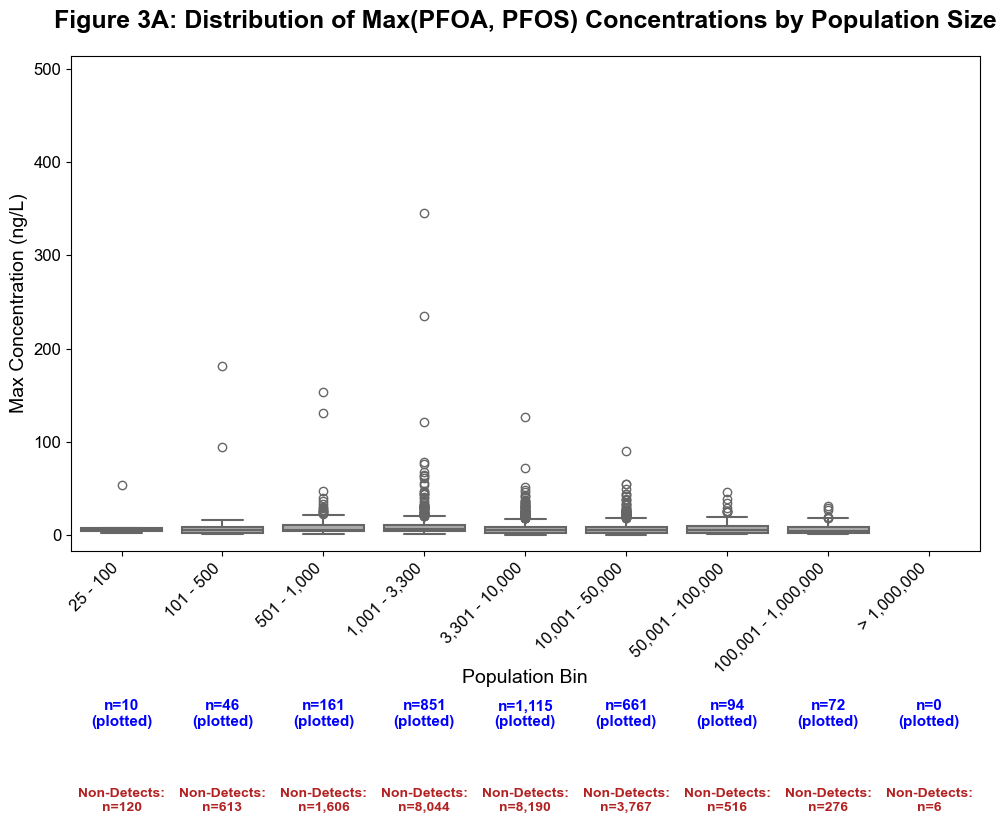

Saved: figure3A_linear.png


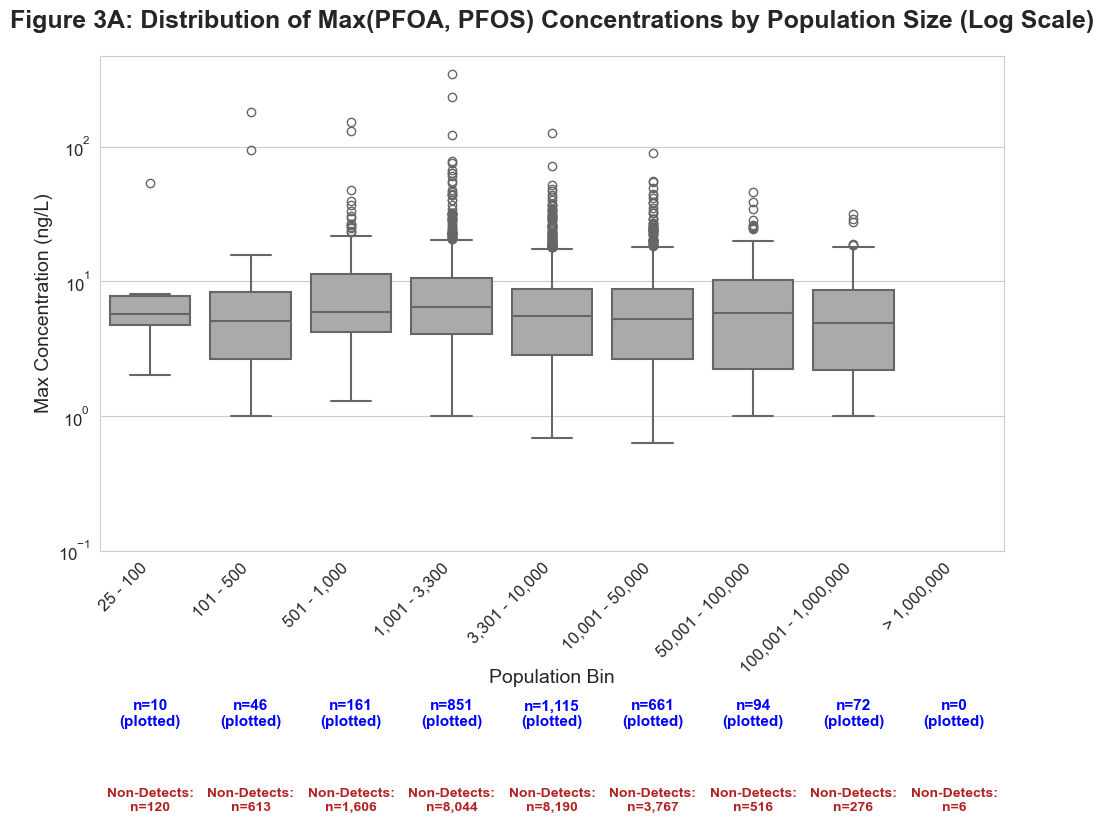

Saved: figure3A_log.png


In [35]:
import seaborn as sns

df['max_pfas_conc_ng'] = df[['PFOA','PFOS']].max(axis=1) * 1000

n_detected = df[df['max_pfas_conc_ng'] > 0].groupby('Population_bin').size().reindex(bin_order).fillna(0).astype(int)
n_below = df[df['max_pfas_conc_ng'] == 0].groupby('Population_bin').size().reindex(bin_order).fillna(0).astype(int)

df_detections = df[df['max_pfas_conc_ng'] > 0]

def make_figure(log_scale=False):
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.set_style("whitegrid")
    
    
    sns.boxplot(
        data=df_detections,
        x='Population_bin',
        y='max_pfas_conc_ng',
        order=bin_order,
        color='#AAAAAA',   # uniform grey — no color differentiation
        showfliers=True,
        ax=ax,
        linewidth=1.5
    )

    suffix = " (Log Scale)" if log_scale else ""
    ax.set_title(
        f"Figure 3A: Distribution of Max(PFOA, PFOS) Concentrations by Population Size{suffix}",
        fontsize=18, pad=20, fontweight='bold'
    )
    ax.set_ylabel("Max Concentration (ng/L)", fontsize=14)
    ax.set_xlabel("Population Bin", fontsize=14, labelpad=-5)
    ax.tick_params(axis='both', labelsize=12)
    plt.xticks(rotation=45, ha='right')

    if log_scale:
        ax.set_yscale('log')
        ax.set_ylim(bottom=0.1)   # avoid log(0) issues
    else:
        y_min, y_max = ax.get_ylim()
        ax.set_ylim(y_min, y_max + (y_max - y_min) * 0.4)

    for i, bin_name in enumerate(bin_order):
        plt.text(i, -0.30, f"n={n_detected[bin_name]:,}\n(plotted)",
                 transform=ax.get_xaxis_transform(),
                 ha='center', va='top', fontsize=11, color='blue', fontweight='bold')
        plt.text(i, -0.48, f"Non-Detects:\nn={n_below[bin_name]:,}",
                 transform=ax.get_xaxis_transform(),
                 ha='center', va='top', fontsize=10, color='firebrick', fontweight='bold')

    plt.subplots_adjust(bottom=0.35)
    plt.tight_layout()
    fname = "figure3A_log.png" if log_scale else "figure3A_linear.png"
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved: {fname}")

make_figure(log_scale=False)
make_figure(log_scale=True)


In [36]:
# checking if any entry points with pop bin > 1,000,000 has exceeded any threshold
exceed_by_bin.loc["> 1,000,000"]

exceeds_4     0.0
exceeds_8     0.0
exceeds_12    0.0
exceeds_20    0.0
exceeds_40    0.0
Name: > 1,000,000, dtype: float64

In [37]:
# no. of entry points with pop bin > 1,000,000 
(df["Population_bin"] == "> 1,000,000").sum()

np.int64(6)

In [38]:
# all the entry point with pop bin > 1,000,000. did all of this cause the graph showed no bins
df.loc[df["Population_bin"] == "> 1,000,000"]

,PWSID,FacilityID,PFOA,PFOS,Total_PFAS,POPULATION_SERVED_COUNT,Ep_Population,Population_bin,exceeds,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40,exposure_per_day(ng),max_pfas_conc_ng
8531,IL0316000,00001,0.0,0.0,0.0,2746388.0,1373194.0,"> 1,000,000",False,False,False,False,False,False,0.0,0.0
8532,IL0316000,00002,0.0,0.0,0.0,2746388.0,1373194.0,"> 1,000,000",False,False,False,False,False,False,0.0,0.0
17769,NY7003493,94001,0.0,0.0,0.0,8271000.0,2067750.0,"> 1,000,000",False,False,False,False,False,False,0.0,0.0
17770,NY7003493,94002,0.0,0.0,0.0,8271000.0,2067750.0,"> 1,000,000",False,False,False,False,False,False,0.0,0.0
17771,NY7003493,94003,0.0,0.0,0.0,8271000.0,2067750.0,"> 1,000,000",False,False,False,False,False,False,0.0,0.0
17772,NY7003493,94004,0.0,0.0,0.0,8271000.0,2067750.0,"> 1,000,000",False,False,False,False,False,False,0.0,0.0


### Figure 3b: Distributed of Max(PFOA, PFOS) Concentrations (Full Sample)
Unlike the previous chart that focused only on detections, this boxplot includes the non-detects. This gives a more realistic look at the median contamination levels across the country, as most systems actually sit at the bottom of the scale.

The codes after the graph is to verify if the population bin more than 1 million didnt really have any Facility ID that exceeded any regulatory thresholds.

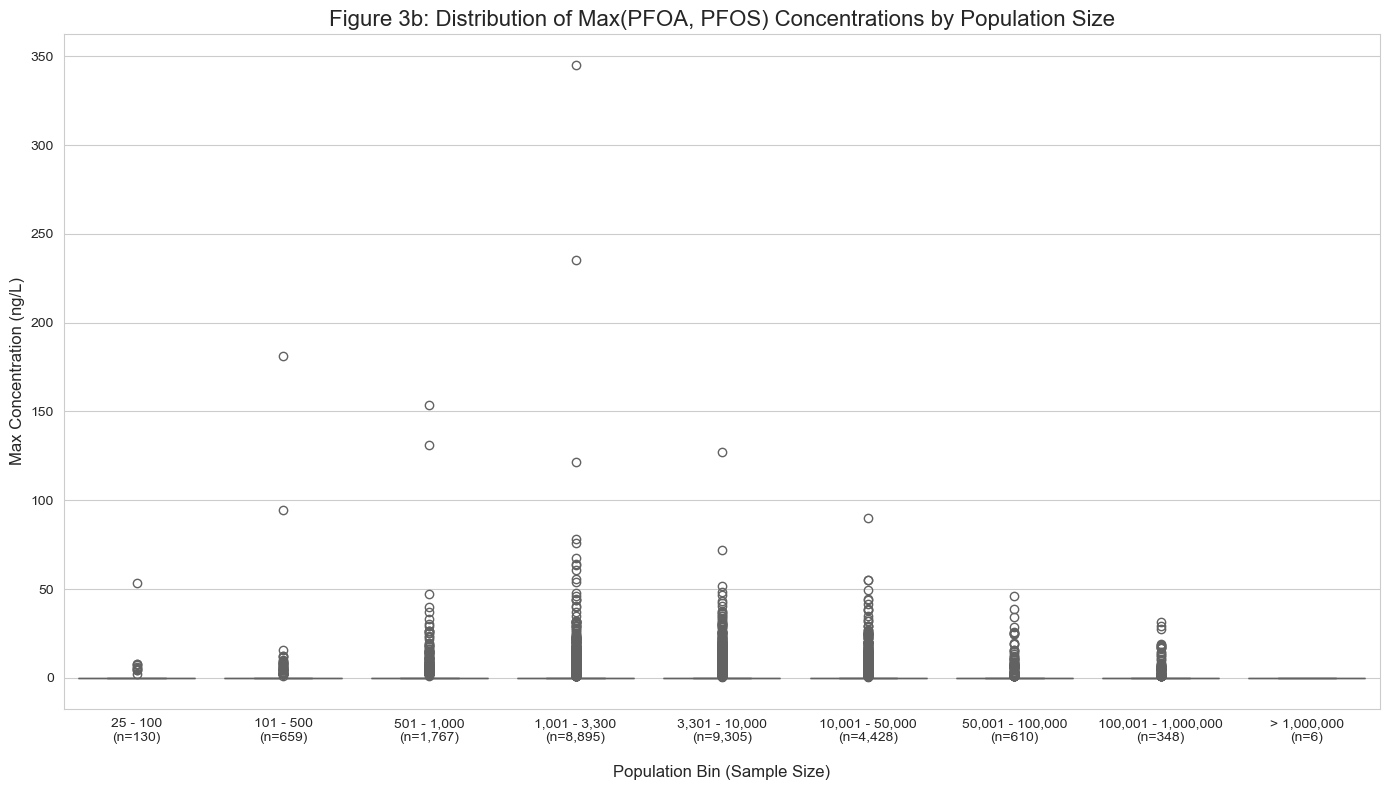

In [39]:

# Calculate counts
n_counts = df.groupby('Population_bin').size().reindex(bin_order)
new_x_labels = [f"{bin_name}\n(n={n_counts[bin_name]:,})" for bin_name in bin_order]

# Initialize Plot
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

ax = sns.boxplot(
    data=df, 
    x='Population_bin', 
    y='max_pfas_conc_ng', 
    order=bin_order,
    hue='Population_bin',
    legend=False,
    palette="Set3",
    showfliers=True
)

# Set the tick positions first, then the labels
ax.set_xticks(range(len(new_x_labels))) 
ax.set_xticklabels(new_x_labels)


plt.title("Figure 3b: Distribution of Max(PFOA, PFOS) Concentrations by Population Size", fontsize=16)
plt.xlabel("Population Bin (Sample Size)", fontsize=12, labelpad=15)
plt.ylabel("Max Concentration (ng/L)", fontsize=12)

plt.xticks(rotation=0) 


plt.tight_layout()
plt.show()

In [40]:
df

,PWSID,FacilityID,PFOA,PFOS,Total_PFAS,POPULATION_SERVED_COUNT,Ep_Population,Population_bin,exceeds,exceeds_4,exceeds_8,exceeds_12,exceeds_20,exceeds_40,exposure_per_day(ng),max_pfas_conc_ng
0,AK2110342,29349,0.0,0.0,0.0,38526.0,19263.0,"10,001 - 50,000",False,False,False,False,False,False,0.0,0.0
1,AK2110342,29360,0.0,0.0,0.0,38526.0,19263.0,"10,001 - 50,000",False,False,False,False,False,False,0.0,0.0
2,AK2110601,10001,0.0,0.0,0.0,10947.0,5474.0,"3,301 - 10,000",False,False,False,False,False,False,0.0,0.0
3,AK2110601,10004,0.0,0.0,0.0,10947.0,5474.0,"3,301 - 10,000",False,False,False,False,False,False,0.0,0.0
4,AK2120232,TP001,0.0,0.0,0.0,8937.0,8937.0,"3,301 - 10,000",False,False,False,False,False,False,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26143,WY5601569,TP02,0.0,0.0,0.0,580.0,580.0,"501 - 1,000",False,False,False,False,False,False,0.0,0.0
26144,WY5680074,TP01,0.0,0.0,0.0,4300.0,4300.0,"3,301 - 10,000",False,False,False,False,False,False,0.0,0.0
26145,WY5680085,TP01,0.0,0.0,0.0,7675.0,7675.0,"3,301 - 10,000",False,False,False,False,False,False,0.0,0.0
26146,WY5680095,TP02,0.0,0.0,0.0,4514.0,4514.0,"3,301 - 10,000",False,False,False,False,False,False,0.0,0.0
